<div class="hero">
  <p class="eyebrow">DEEP LEARNING 2026 · PROYECTO 2</p>
  <h1>Eryndor: Guardianes del Velo</h1>
  <p class="subtitle">Diseño generativo de personajes para un RPG pixel art de aventura y magia</p>
  <div class="hero-grid">
    <div><span>MODELO BASE</span><strong>DCGAN</strong></div>
    <div><span>RESOLUCIÓN</span><strong>64 × 64</strong></div>
    <div><span>EXPERIMENTOS</span><strong>3</strong></div>
    <div><span>GALERÍA</span><strong>10 / 200</strong></div>
  </div>
</div>

**Universidad del Valle de Guatemala**  
Deep Learning · 2026

> **Integrantes:** Pablo Daniel Barillas Moreno · Wilson Alejandro Calderón  
> **Estado:** fase 7 preparada para Google Colab — entrenamiento aún en 1 de 60 épocas.
> **Regla principal:** ninguna imagen final puede proceder de un generador externo.

In [1]:
from IPython.display import HTML, Image as IPyImage, display

display(HTML(r"""
<style>
:root {
  --obsidian:#171A24; --deep:#2B1E3E; --cosmic:#4A4E8F;
  --cyan:#4FC3C8; --gold:#D6A34A; --silver:#E6E6FA;
  --lavender:#A490C2; --moss:#79A879; --line:#D9D7E8;
}
.container { max-width: 1180px !important; }
.hero {
  padding: 34px 38px; margin: 12px 0 28px; border-radius: 20px; color: var(--silver);
  background: radial-gradient(circle at 86% 18%, rgba(79,195,200,.22), transparent 23%),
              linear-gradient(135deg,var(--obsidian),var(--deep) 56%,var(--cosmic));
  box-shadow: 0 18px 42px rgba(23,26,36,.22);
}
.hero h1 { color:white; font-size:2.55rem; margin:.2rem 0; letter-spacing:-.025em; }
.hero .subtitle { color:var(--silver); opacity:.9; font-size:1.1rem; margin:.25rem 0 1.5rem; }
.eyebrow { color:var(--cyan); font-size:.72rem; font-weight:800; letter-spacing:.16em; }
.hero-grid { display:grid; grid-template-columns:repeat(4,1fr); gap:10px; }
.hero-grid div { padding:11px 13px; border-radius:11px; border:1px solid rgba(230,230,250,.18); background:rgba(255,255,255,.07); }
.hero-grid span { display:block; font-size:.63rem; letter-spacing:.1em; opacity:.68; }
.hero-grid strong { display:block; margin-top:3px; color:white; }
h2 { color:var(--deep); border-bottom:2px solid var(--line); padding-bottom:.35rem; margin-top:2.2rem; }
h3 { color:var(--cosmic); margin-top:1.5rem; }
.callout { border-left:5px solid var(--cosmic); background:#F2F0F8; padding:15px 17px; border-radius:11px; margin:14px 0; }
.callout.magic { border-color:var(--cyan); background:#ECF9F9; }
.callout.gold { border-color:var(--gold); background:#FFF7E7; }
.kpis { display:grid; grid-template-columns:repeat(4,1fr); gap:10px; margin:15px 0; }
.kpi { border:1px solid var(--line); border-radius:12px; padding:14px; background:white; }
.kpi span { display:block; color:#66627A; font-size:.68rem; letter-spacing:.08em; text-transform:uppercase; }
.kpi strong { display:block; color:var(--deep); font-size:1.35rem; margin-top:3px; }
table { font-size:.91rem; }
code { color:#60428F; }
</style>
"""))

## 1. Pregunta y criterio de éxito

> **Pregunta central:** ¿puede una GAN entrenada sobre sprites abiertos y consistentes generar personajes de Eryndor que sean plausibles, diversos y distintos de sus vecinos más cercanos en entrenamiento?

El proyecto se considerará exitoso si:

1. el código regenera la galería a partir del checkpoint y los vectores `z`;
2. se obtienen al menos diez personajes visualmente distintos;
3. la rejilla de ruido fijo muestra evolución sin colapso persistente;
4. los vecinos más cercanos no son copias casi exactas;
5. la comparación de pérdida y estabilización mantiene una sola variable modificada por experimento.

## 2. Universo visual

Eryndor quedó fragmentado después de la **Ruptura Celeste**. La magia se solidifica en minerales luminosos y los Guardianes del Velo recorren fortalezas derruidas, bosques húmedos y observatorios olvidados para cerrar grietas arcanas.

<div class="callout magic"><strong>Lenguaje visual.</strong> Pixel art detallado de 64 × 64, cuerpo completo, perspectiva ortográfica elevada, materiales gastados y una paleta oscura con acentos de cian mineral, oro brasa y amatista.</div>

Roles narrativos posibles: guardián rúnico, arcanista de ceniza, explorador del musgo, alquimista solar y oráculo del abismo. Los nombres y roles finales se asignarán después de observar la galería, no antes de entrenar.

## 3. Configuración y reproducibilidad

Esta celda solo prepara rutas y lee la configuración. El entrenamiento se realizará preferentemente con GPU en Colab o Kaggle y conservará checkpoints cada cinco épocas.

In [2]:
from pathlib import Path
import json
import os
import random
import sys

import numpy as np
import pandas as pd
import torch
import yaml

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

with open(ROOT / "configs" / "experiments.yaml", encoding="utf-8") as file:
    CONFIG = yaml.safe_load(file)

SEED = int(CONFIG["training"]["model_seed"])
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PATHS = {
    "raw": ROOT / "data" / "raw",
    "processed": ROOT / "data" / "processed",
    "checkpoints": ROOT / "checkpoints",
    "fixed_noise": ROOT / "artifacts" / "fixed_noise",
    "curves": ROOT / "artifacts" / "curves",
    "neighbors": ROOT / "artifacts" / "nearest_neighbors",
    "metrics": ROOT / "artifacts" / "metrics",
    "gallery": ROOT / "galeria",
}
for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo: {DEVICE}")
print(f"Proyecto: {CONFIG['project']['name']}")
print(f"Semilla: {SEED}")

PyTorch: 2.13.0+cpu
Dispositivo: cpu
Proyecto: Eryndor: Guardianes del Velo
Semilla: 42


In [3]:
display(HTML(f"""
<div class="kpis">
  <div class="kpi"><span>Dataset objetivo</span><strong>{CONFIG['project']['dataset_size']:,}</strong></div>
  <div class="kpi"><span>Dimensión latente</span><strong>{CONFIG['training']['latent_dim']}</strong></div>
  <div class="kpi"><span>Épocas</span><strong>{CONFIG['training']['epochs']}</strong></div>
  <div class="kpi"><span>Candidatos finales</span><strong>{CONFIG['gallery']['candidate_count']}</strong></div>
</div>
"""))

## 4. Datos, procedencia y licencia

Se utilizó arte del **Universal LPC Spritesheet Character Generator**, basado en Liberated Pixel Cup. El pipeline compuso 4,096 personajes deterministas, extrajo el cuadro frontal de 64 × 64 y deduplicó las imágenes antes de entrenar.

- Repositorio: https://github.com/LiberatedPixelCup/Universal-LPC-Spritesheet-Character-Generator
- Guía visual: https://lpc.opengameart.org/static/LPC-Style-Guide/build/styleguide.html
- Atribución: se conserva el `CREDITS.csv` del proyecto y el detalle de las 254 capas utilizadas en `docs/LPC_CREDITS_USED.csv`.

<div class="callout gold"><strong>Control legal y ético.</strong> LPC combina varias licencias abiertas. Las 254 capas usadas tienen crédito resuelto (0 pendientes), el material base no se presenta como propietario y ninguna imagen externa se usará como salida final de la GAN.</div>

## 5. Construcción reproducible del dataset

El conjunto se generó con semilla `2026` mediante composición alfa de capas compatibles. Cada imagen sigue este orden: fondo obsidiana, arma posterior, cuerpo recoloreado, piernas, calzado, torso, hombros, cabello recoloreado, sombrero y arma frontal. Solo se admitieron piezas coherentes con fantasía RPG.

```powershell
powershell -ExecutionPolicy Bypass -File scripts/fetch_lpc.ps1
python scripts/prepare_dataset.py --count 4096
```

El pipeline guarda las imágenes en `data/processed/sprites/`, un `manifest.csv` por imagen, los créditos filtrados, figuras de auditoría y un resumen JSON. Los hashes SHA-256 se calculan sobre píxeles RGB; una colisión visual se descarta antes de guardar.

In [4]:
summary_path = PATHS["metrics"] / "dataset_summary.json"
loader_audit_path = PATHS["metrics"] / "dataloader_smoke_test.json"
manifest_path = PATHS["processed"] / "manifest.csv"

with open(summary_path, encoding="utf-8") as file:
    DATASET_SUMMARY = json.load(file)
with open(loader_audit_path, encoding="utf-8") as file:
    LOADER_AUDIT = json.load(file)

manifest = pd.read_csv(manifest_path)
assert len(manifest) == CONFIG["project"]["dataset_size"]
assert DATASET_SUMMARY["duplicate_hashes"] == 0
assert DATASET_SUMMARY["missing_files"] == 0

display(HTML(f"""
<div class="kpis">
  <div class="kpi"><span>Imágenes</span><strong>{DATASET_SUMMARY['image_count']:,}</strong></div>
  <div class="kpi"><span>Hashes duplicados</span><strong>{DATASET_SUMMARY['duplicate_hashes']}</strong></div>
  <div class="kpi"><span>Cabellos</span><strong>{DATASET_SUMMARY['unique_hair_styles']}</strong></div>
  <div class="kpi"><span>Ocupación media</span><strong>{DATASET_SUMMARY['foreground_ratio']['mean']:.1%}</strong></div>
</div>
"""))

manifest[["image_id", "body_type", "skin_tone", "hair_color", "torso_style", "role_hint"]].head(8)

,image_id,body_type,skin_tone,hair_color,torso_style,role_hint
0,eryndor_0000,female,amber,ash,armour/plate/female,Guardián rúnico
1,eryndor_0001,male,brown,black,clothes/longsleeve/longsleeves_cuffed/male,Caminante de Eryndor
2,eryndor_0002,female,brown,black,clothes/longsleeve/longsleeves/female,Caminante de Eryndor
3,eryndor_0003,male,taupe,blonde,clothes/vest/male,Caminante de Eryndor
4,eryndor_0004,female,bronze,blonde,armour/legion/female,Guardián rúnico
5,eryndor_0005,male,black,raven,clothes/longsleeve/longsleeves/male,Caminante de Eryndor
6,eryndor_0006,male,amber,black,clothes/longsleeve/longsleeve/male,Caminante de Eryndor
7,eryndor_0007,female,taupe,dark_brown,armour/leather/female,Guardián rúnico


### 5.1 Auditoría visual y distribuciones

La muestra se fija con la misma semilla de construcción. La primera figura permite detectar capas vacías, desplazamientos o contaminación del fondo; la segunda resume balance corporal, tonos de piel, cabello y ocupación.

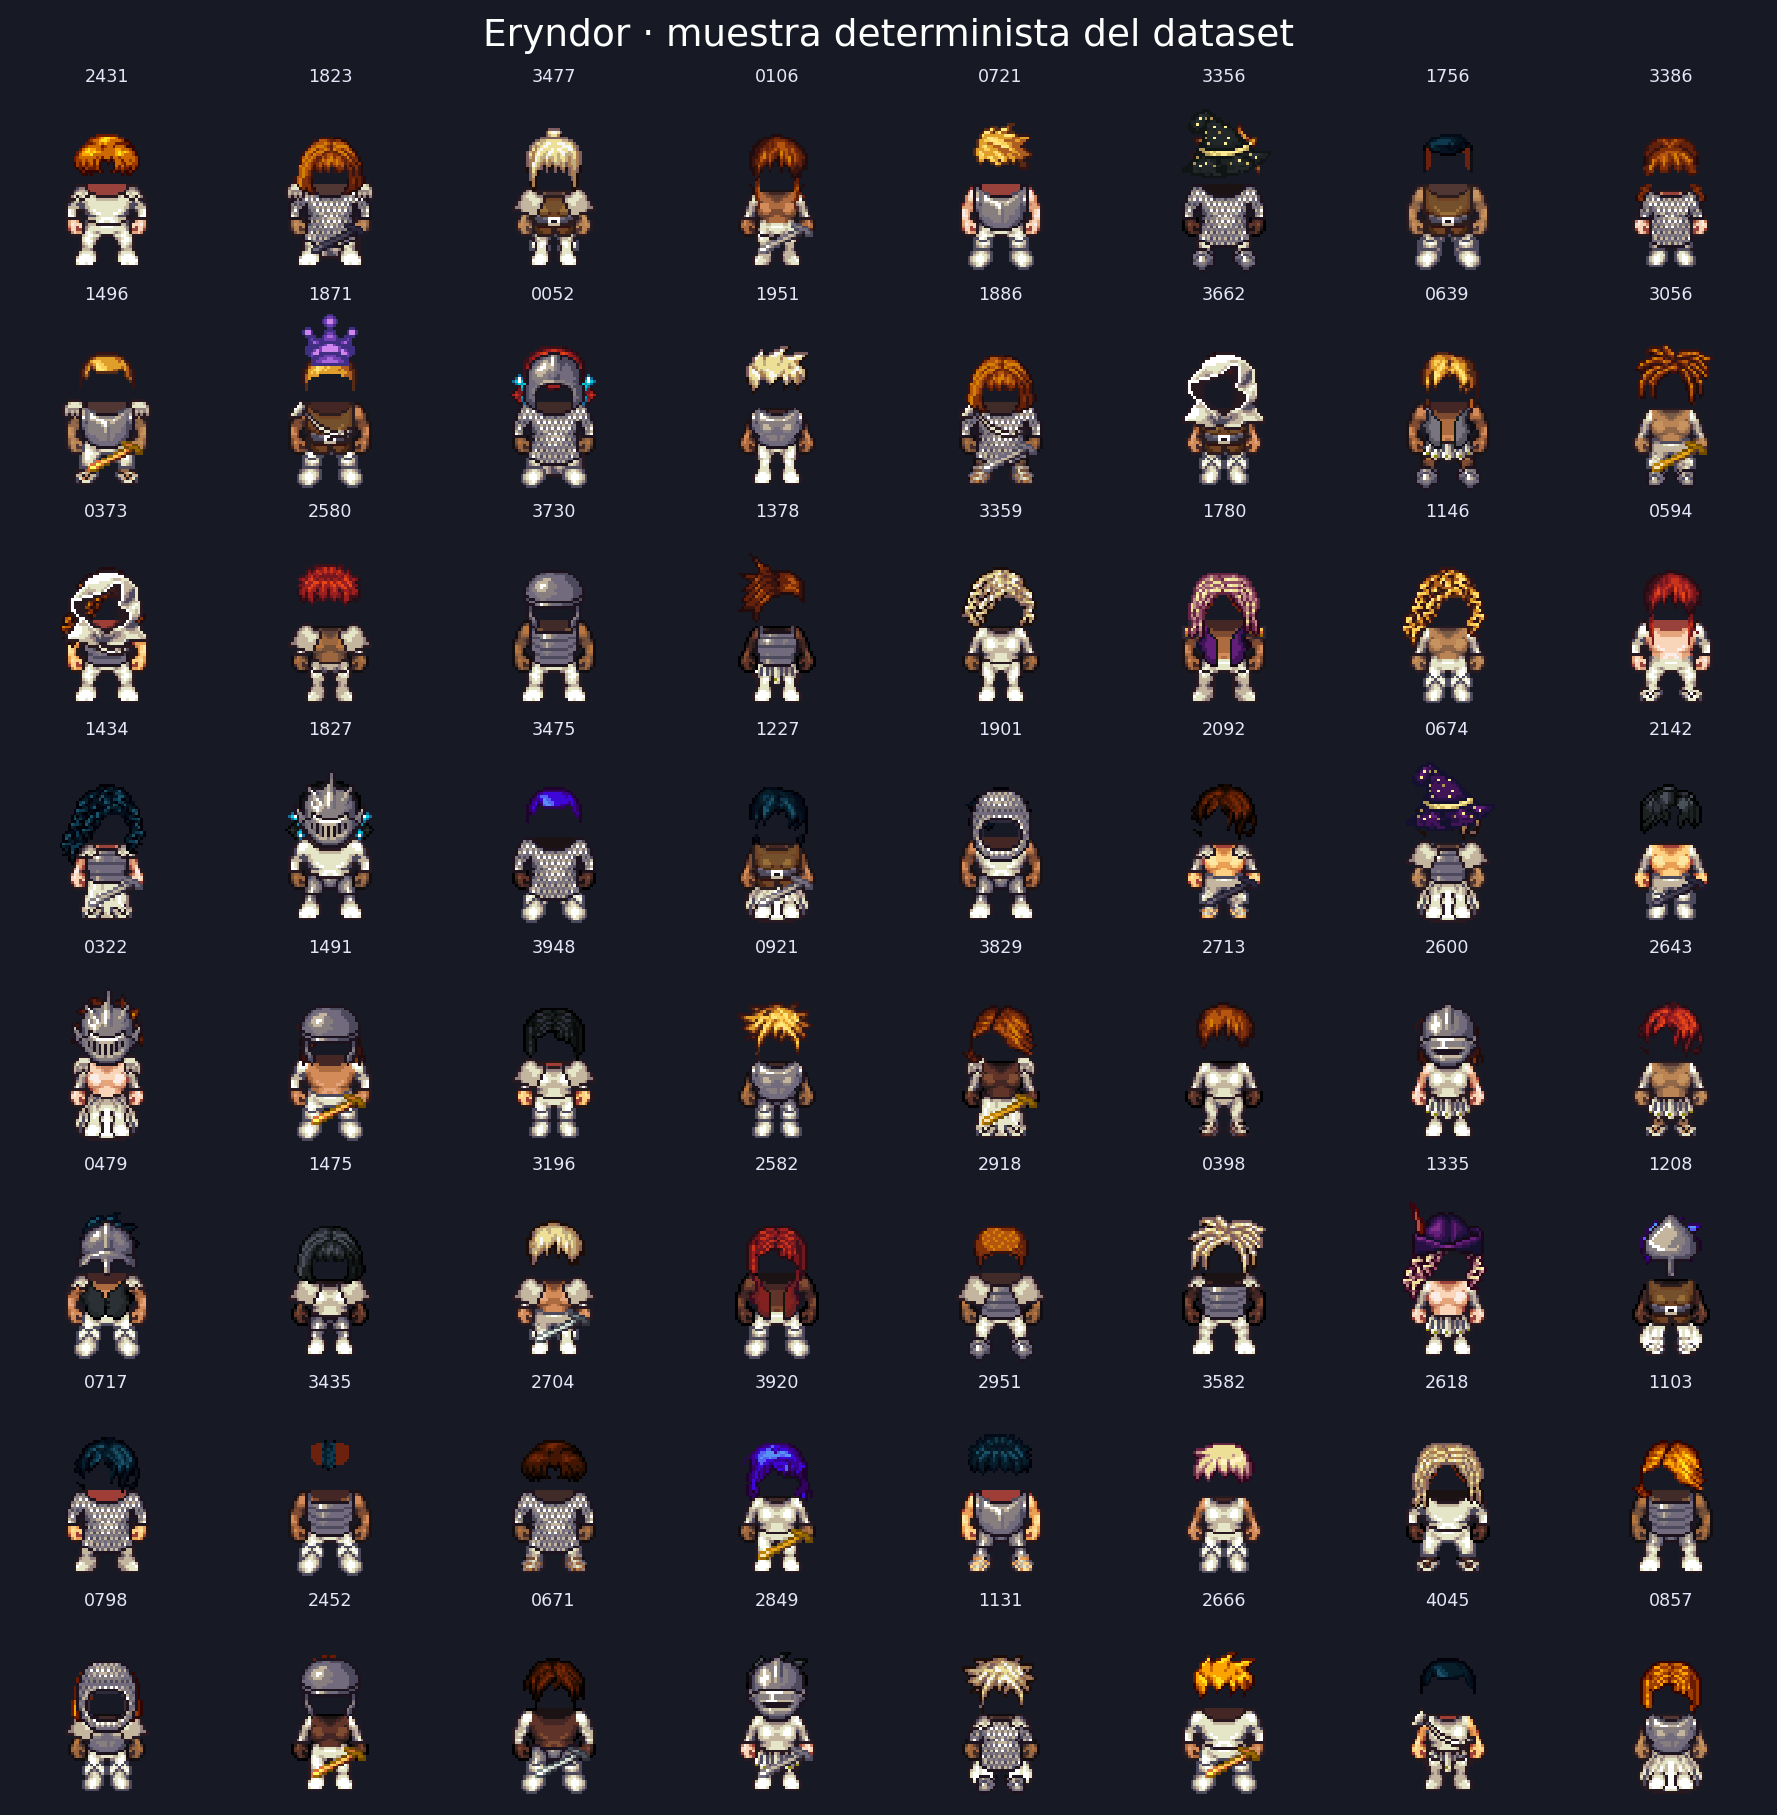

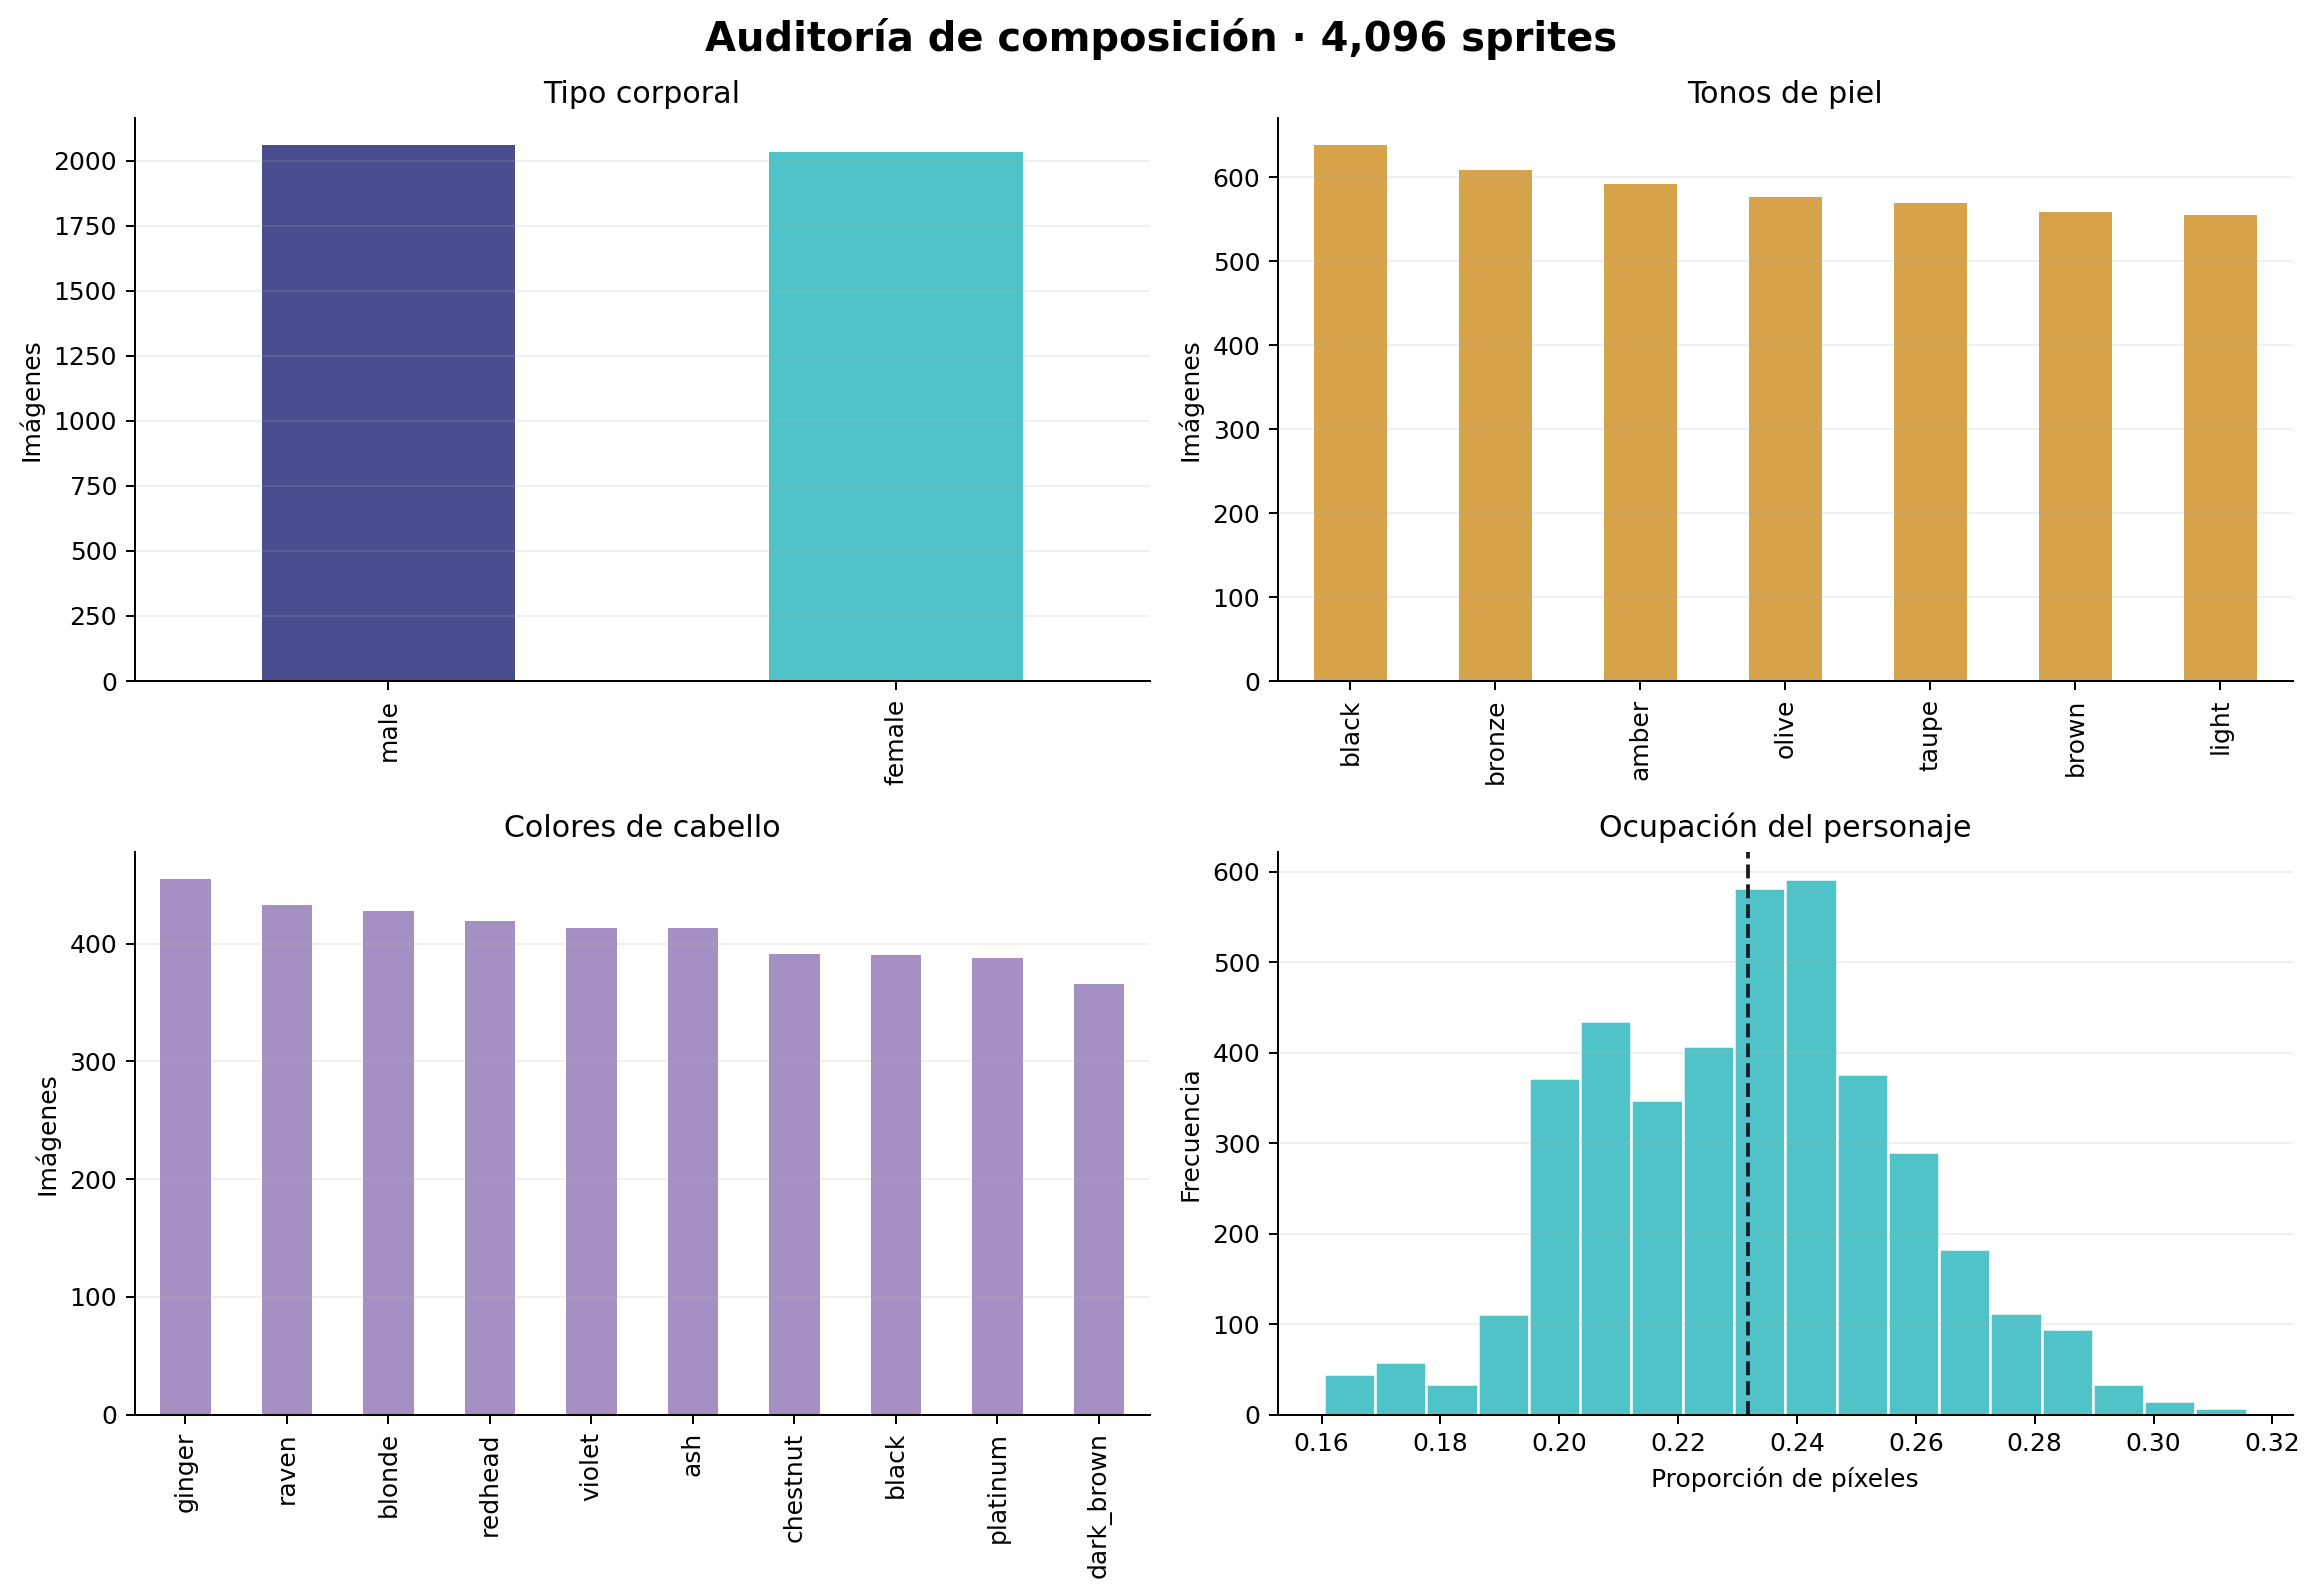

In [5]:
display(IPyImage(filename=str(ROOT / "artifacts" / "dataset" / "dataset_contact_sheet.png"), width=900))
display(IPyImage(filename=str(ROOT / "artifacts" / "dataset" / "dataset_distributions.png"), width=900))

### 5.2 Lectura de resultados

- Se obtuvieron **4,096 imágenes únicas**, sin archivos faltantes y con **0 hashes duplicados**.
- El balance corporal fue 2,060 `male` y 2,036 `female`; la diferencia es de solo 24 imágenes.
- Los siete tonos de piel reúnen entre 555 y 638 casos; los diez colores de cabello, entre 366 y 455.
- Hay **44 estilos de cabello** y **18 estilos de torso** distintos.
- La ocupación media es **23.18%** del lienzo, con rango **16.04%–31.57%**. Esto conserva margen alrededor del personaje sin volverlo demasiado pequeño.

<div class="callout"><strong>Limitación.</strong> El dataset es composicional: comparte bases anatómicas y trabaja con una sola pose frontal. Por ello ofrece control visual y legal, pero no representa toda la variabilidad de personajes ilustrados. Los vecinos cercanos y la diversidad de la galería deberán interpretarse dentro de ese universo limitado.</div>

### 5.3 Contrato tensorial y `DataLoader`

El entrenamiento recibe lotes `float32` de forma `[B, 3, 64, 64]`, normalizados a `[-1, 1]`. El flip horizontal se aplica durante entrenamiento con probabilidad 0.5 y no altera el dataset almacenado.

In [6]:
from src.data import build_dataloader

loader = build_dataloader(
    manifest_path=manifest_path,
    project_root=ROOT,
    batch_size=CONFIG["training"]["batch_size"],
    seed=SEED,
    horizontal_flip=True,
    num_workers=0,
)
batch = next(iter(loader))

runtime_audit = {
    "shape": list(batch.shape),
    "dtype": str(batch.dtype),
    "min": float(batch.min()),
    "max": float(batch.max()),
    "finite": bool(torch.isfinite(batch).all()),
}
assert runtime_audit["shape"] == [64, 3, 64, 64]
assert runtime_audit["min"] >= -1.0 and runtime_audit["max"] <= 1.0
runtime_audit

{'shape': [64, 3, 64, 64],
 'dtype': 'torch.float32',
 'min': -1.0,
 'max': 1.0,
 'finite': True}

## 6. Experimentos pre-registrados

| Experimento | Pérdida | Estabilización | Hipótesis resumida |
|---|---|---|---|
| A · Baseline | BCE no saturante | Ninguna adicional | Debe producir siluetas reconocibles en un conjunto consistente. |
| B · Pérdida | Hinge | Ninguna adicional | Puede mejorar nitidez y mantener gradientes útiles. |
| C · Estabilización | BCE no saturante | Spectral normalization en D | Debe reducir periodos de dominio excesivo del discriminador. |

Los datos, semilla, arquitectura, épocas, optimizadores y ruido de evaluación permanecerán iguales. El plan detallado está en `docs/PLAN_EXPERIMENTAL.md`.

In [7]:
experimentos = pd.DataFrame(CONFIG["experiments"])
experimentos

,id,loss,spectral_norm_discriminator
0,baseline_bce,bce_non_saturating,False
1,hinge_loss,hinge,False
2,bce_spectral_norm,bce_non_saturating,True


## 7. Implementación DCGAN

### 7.1 Generador

El generador proyecta `z ∈ R¹²⁸` desde 1 × 1 hasta 64 × 64 mediante cinco convoluciones transpuestas. Los cuatro bloques internos usan BatchNorm y ReLU; la salida RGB usa `tanh`, compatible con datos normalizados a `[-1, 1]`.

### 7.2 Discriminador

El discriminador reduce 64 × 64 hasta un logit escalar mediante cinco convoluciones. Usa LeakyReLU 0.2 y BatchNorm desde el segundo bloque. No contiene sigmoid: BCE opera directamente sobre logits y hinge interpreta la salida como puntuación no calibrada.

### 7.3 Inicialización y optimización

- Convoluciones: `N(0, 0.02)`.
- BatchNorm: pesos `N(1, 0.02)` y sesgos en cero.
- Adam: `lr=2e-4`, `betas=(0.5, 0.999)`.
- El experimento C aplica spectral normalization únicamente a las cinco convoluciones de D.

In [8]:
from src.losses import AdversarialLoss
from src.models import ModelDimensions, build_models, trainable_parameters

dimensions = ModelDimensions(
    latent_dim=CONFIG["training"]["latent_dim"],
    image_channels=CONFIG["project"]["channels"],
    generator_features=CONFIG["training"]["generator_features"],
    discriminator_features=CONFIG["training"]["discriminator_features"],
)

generator_probe, discriminator_probe = build_models(dimensions, False, DEVICE)
noise_probe = torch.randn(2, dimensions.latent_dim, 1, 1, device=DEVICE)
fake_probe = generator_probe(noise_probe)
logit_probe = discriminator_probe(fake_probe)

architecture_check = {
    "z": list(noise_probe.shape),
    "G(z)": list(fake_probe.shape),
    "D(G(z))": list(logit_probe.shape),
    "G_parameters": trainable_parameters(generator_probe),
    "D_parameters": trainable_parameters(discriminator_probe),
    "output_min": float(fake_probe.detach().min()),
    "output_max": float(fake_probe.detach().max()),
}
assert architecture_check["G(z)"] == [2, 3, 64, 64]
assert architecture_check["D(G(z))"] == [2]
architecture_check

{'z': [2, 128, 1, 1],
 'G(z)': [2, 3, 64, 64],
 'D(G(z))': [2],
 'G_parameters': 3806080,
 'D_parameters': 2765568,
 'output_min': -0.8751929402351379,
 'output_max': 0.7240725755691528}

## 8. Smoke test de integración

El comando siguiente ejecuta ocho actualizaciones reales del baseline, guarda ruido fijo antes/después, registra pérdidas y logits, prueba las tres variantes y verifica un checkpoint mediante guardado y recarga.

```powershell
python scripts/smoke_test_gan.py
```

Este ensayo usa solo 64 imágenes (`8 pasos × batch 8`). Su propósito es descubrir errores de integración; **no mide la calidad final ni permite elegir un experimento**.

In [9]:
smoke_path = ROOT / "artifacts" / "smoke_test" / "smoke_metrics.json"
if not smoke_path.exists():
    raise FileNotFoundError("Ejecute primero: python scripts/smoke_test_gan.py")
with open(smoke_path, encoding="utf-8") as file:
    SMOKE = json.load(file)

assert SMOKE["status"] == "passed"
assert SMOKE["all_losses_finite"]
assert SMOKE["checkpoint"]["roundtrip_max_abs_error"] == 0.0
assert SMOKE["checkpoint"]["data_generator_restored"]

display(HTML(f"""
<div class="kpis">
  <div class="kpi"><span>Estado</span><strong>{SMOKE['status'].upper()}</strong></div>
  <div class="kpi"><span>Pasos</span><strong>{SMOKE['steps']}</strong></div>
  <div class="kpi"><span>Tiempo CPU</span><strong>{SMOKE['elapsed_seconds']:.2f}s</strong></div>
  <div class="kpi"><span>Error checkpoint</span><strong>{SMOKE['checkpoint']['roundtrip_max_abs_error']:.0f}</strong></div>
</div>
"""))

variant_table = pd.DataFrame(SMOKE["variant_validations"]).T
variant_table[["loss", "fake_shape", "logit_shape", "finite", "spectral_norm_layers", "loss_gradients_finite"]]

,loss,fake_shape,logit_shape,finite,spectral_norm_layers,loss_gradients_finite
baseline_bce,bce_non_saturating,"[2, 3, 64, 64]",[2],True,0,True
hinge_loss,hinge,"[2, 3, 64, 64]",[2],True,0,True
bce_spectral_norm,bce_non_saturating,"[2, 3, 64, 64]",[2],True,5,True


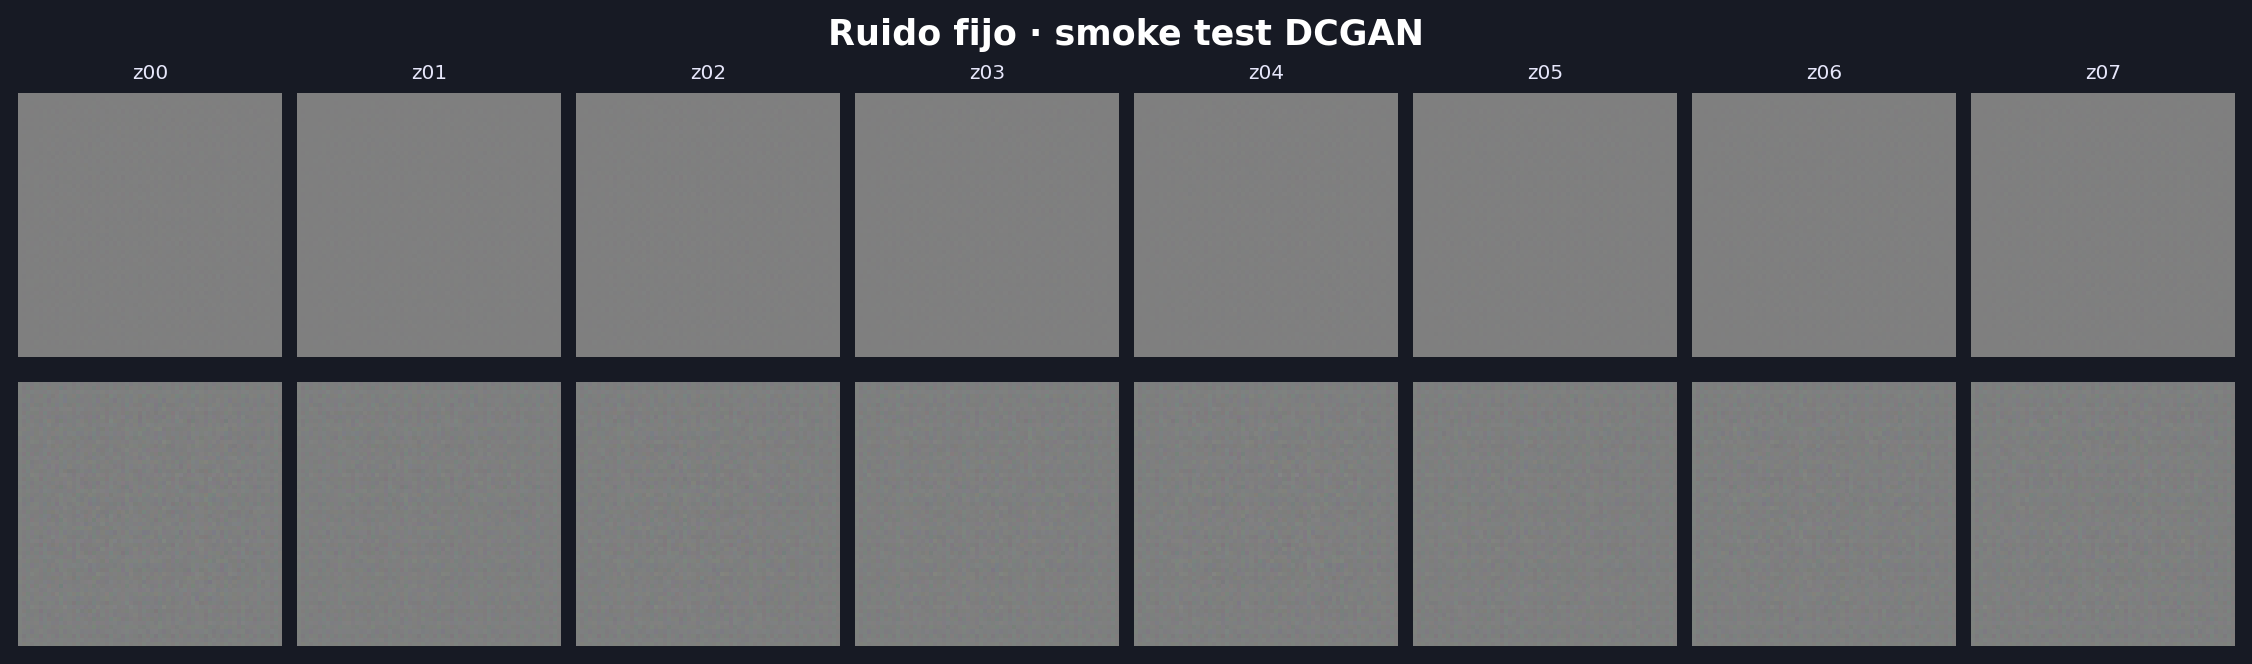

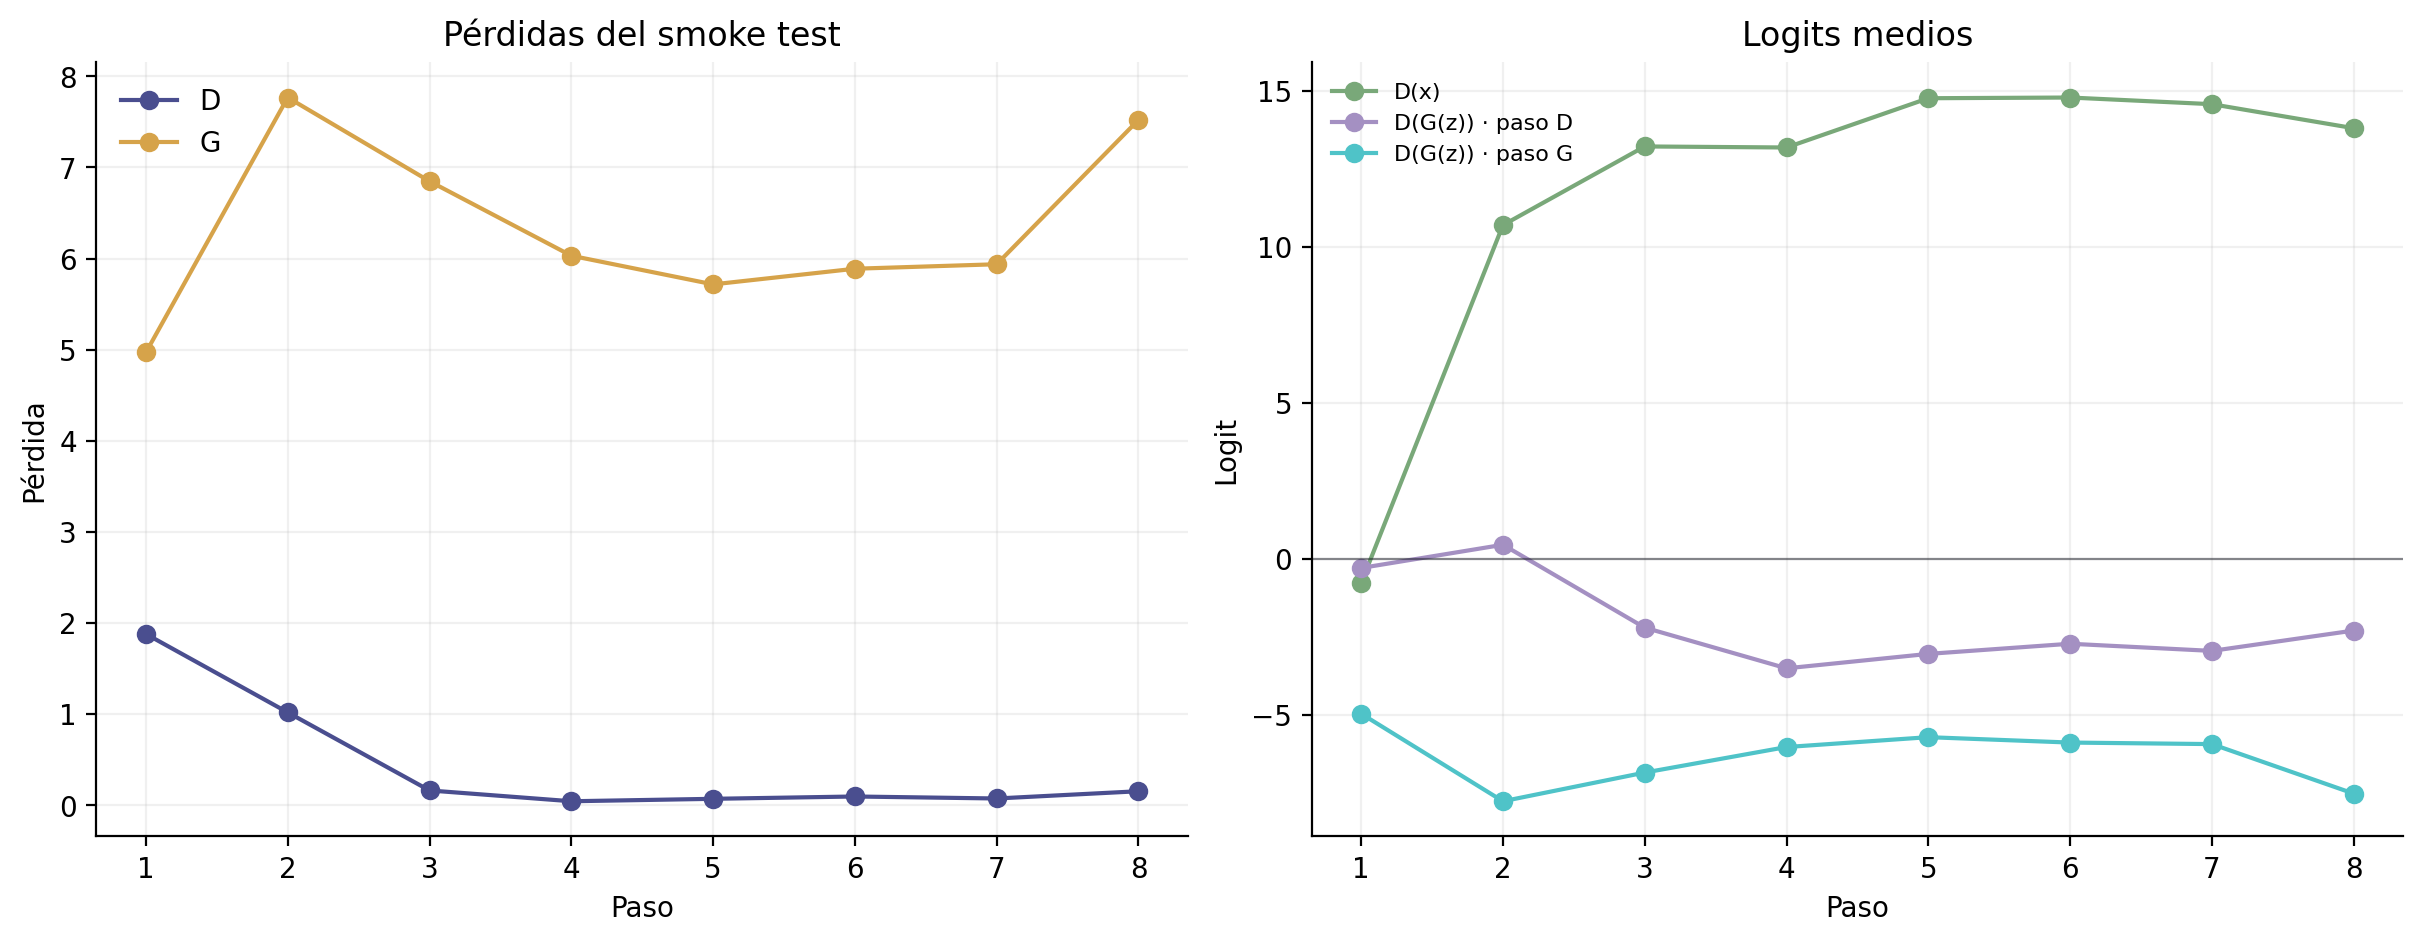

In [10]:
display(IPyImage(filename=str(ROOT / "artifacts" / "smoke_test" / "fixed_noise_comparison.png"), width=1100))
display(IPyImage(filename=str(ROOT / "artifacts" / "smoke_test" / "smoke_training_curves.png"), width=1050))

### 8.1 Interpretación limitada al diagnóstico

- Las pérdidas y logits fueron finitos en los ocho pasos; BCE, hinge y BCE + spectral normalization también produjeron gradientes finitos en sus pruebas unitarias.
- Las tres variantes respetaron `G(z) → [2, 3, 64, 64]` y `D(x) → [2]`. La variante C confirmó spectral normalization en **5 capas**.
- El checkpoint conservó pesos, optimizadores, ruido fijo, paso global, estados aleatorios y el generador que controla el orden del `DataLoader`; tras recargarlo, la salida tuvo error máximo absoluto **0**.
- En el baseline, `loss_D` pasó de **1.879** a **0.153**, mientras `loss_G` pasó de **4.970** a **7.522**. El logit real final llegó a **13.809** y el falso usado por G a **−7.522**: D aprendió mucho más rápido durante este arranque.
- La rejilla sigue siendo ruido gris tenue. Es lo esperado tras solo ocho pasos y no debe presentarse como generación de personajes.

<div class="callout gold"><strong>Señal para monitorear.</strong> El dominio temprano de D no invalida el pipeline, pero sí obliga a observar la rejilla fija y los logits durante las primeras épocas. El experimento de normalización espectral ya está implementado precisamente para evaluar si reduce este comportamiento.</div>

## 9. Avance real de la fase 4

Los tres experimentos ya procesaron una época completa sobre las 4,096 imágenes (`64 pasos × batch 64`). Se conservaron el checkpoint reanudable, las métricas por paso y época, y la rejilla del mismo ruido fijo.

<div class="callout gold"><strong>Lectura correcta.</strong> Una época verifica que el protocolo completo funciona, pero no permite seleccionar el mejor modelo. Además, BCE y hinge tienen escalas de pérdida distintas, por lo que sus valores no deben compararse como si fueran una misma métrica.</div>

In [11]:
comparison_path = ROOT / "artifacts" / "experiments" / "comparison_summary.csv"
status_path = ROOT / "artifacts" / "experiments" / "comparison_status.json"
if not comparison_path.exists() or not status_path.exists():
    raise FileNotFoundError("Ejecute primero los experimentos y scripts/compare_experiments.py")

phase4_summary = pd.read_csv(comparison_path)
with open(status_path, encoding="utf-8") as file:
    PHASE4_STATUS = json.load(file)

expected = {"baseline_bce", "hinge_loss", "bce_spectral_norm"}
assert set(phase4_summary["experiment"]) == expected
assert (phase4_summary["completed_epochs"] >= 1).all()

display(phase4_summary[[
    "experiment", "completed_epochs", "loss_d", "loss_g", "real_logit",
    "fake_logit_g", "fixed_pairwise_l2", "mean_epoch_seconds"
]].style.format({
    "loss_d": "{:.4f}", "loss_g": "{:.4f}", "real_logit": "{:.4f}",
    "fake_logit_g": "{:.4f}", "fixed_pairwise_l2": "{:.4f}",
    "mean_epoch_seconds": "{:.1f}"
}).hide(axis="index"))

display(HTML(f"""
<div class="kpis">
  <div class="kpi"><span>Experimentos iniciados</span><strong>{PHASE4_STATUS['experiments_available']} / 3</strong></div>
  <div class="kpi"><span>Progreso por corrida</span><strong>1 / {PHASE4_STATUS['target_epochs']}</strong></div>
  <div class="kpi"><span>Cómputo CPU restante</span><strong>≈ {PHASE4_STATUS['estimated_remaining_cpu_hours']:.1f} h</strong></div>
  <div class="kpi"><span>Selección final</span><strong>Pendiente</strong></div>
</div>
"""))

experiment,completed_epochs,loss_d,loss_g,real_logit,fake_logit_g,fixed_pairwise_l2,mean_epoch_seconds
baseline_bce,1,0.1156,8.5477,8.1657,-8.5457,0.0551,184.4
hinge_loss,1,0.2482,15.2575,8.4436,-15.2575,0.0860,204.6
bce_spectral_norm,1,0.0760,6.8625,5.9985,-6.8588,0.0618,185.2


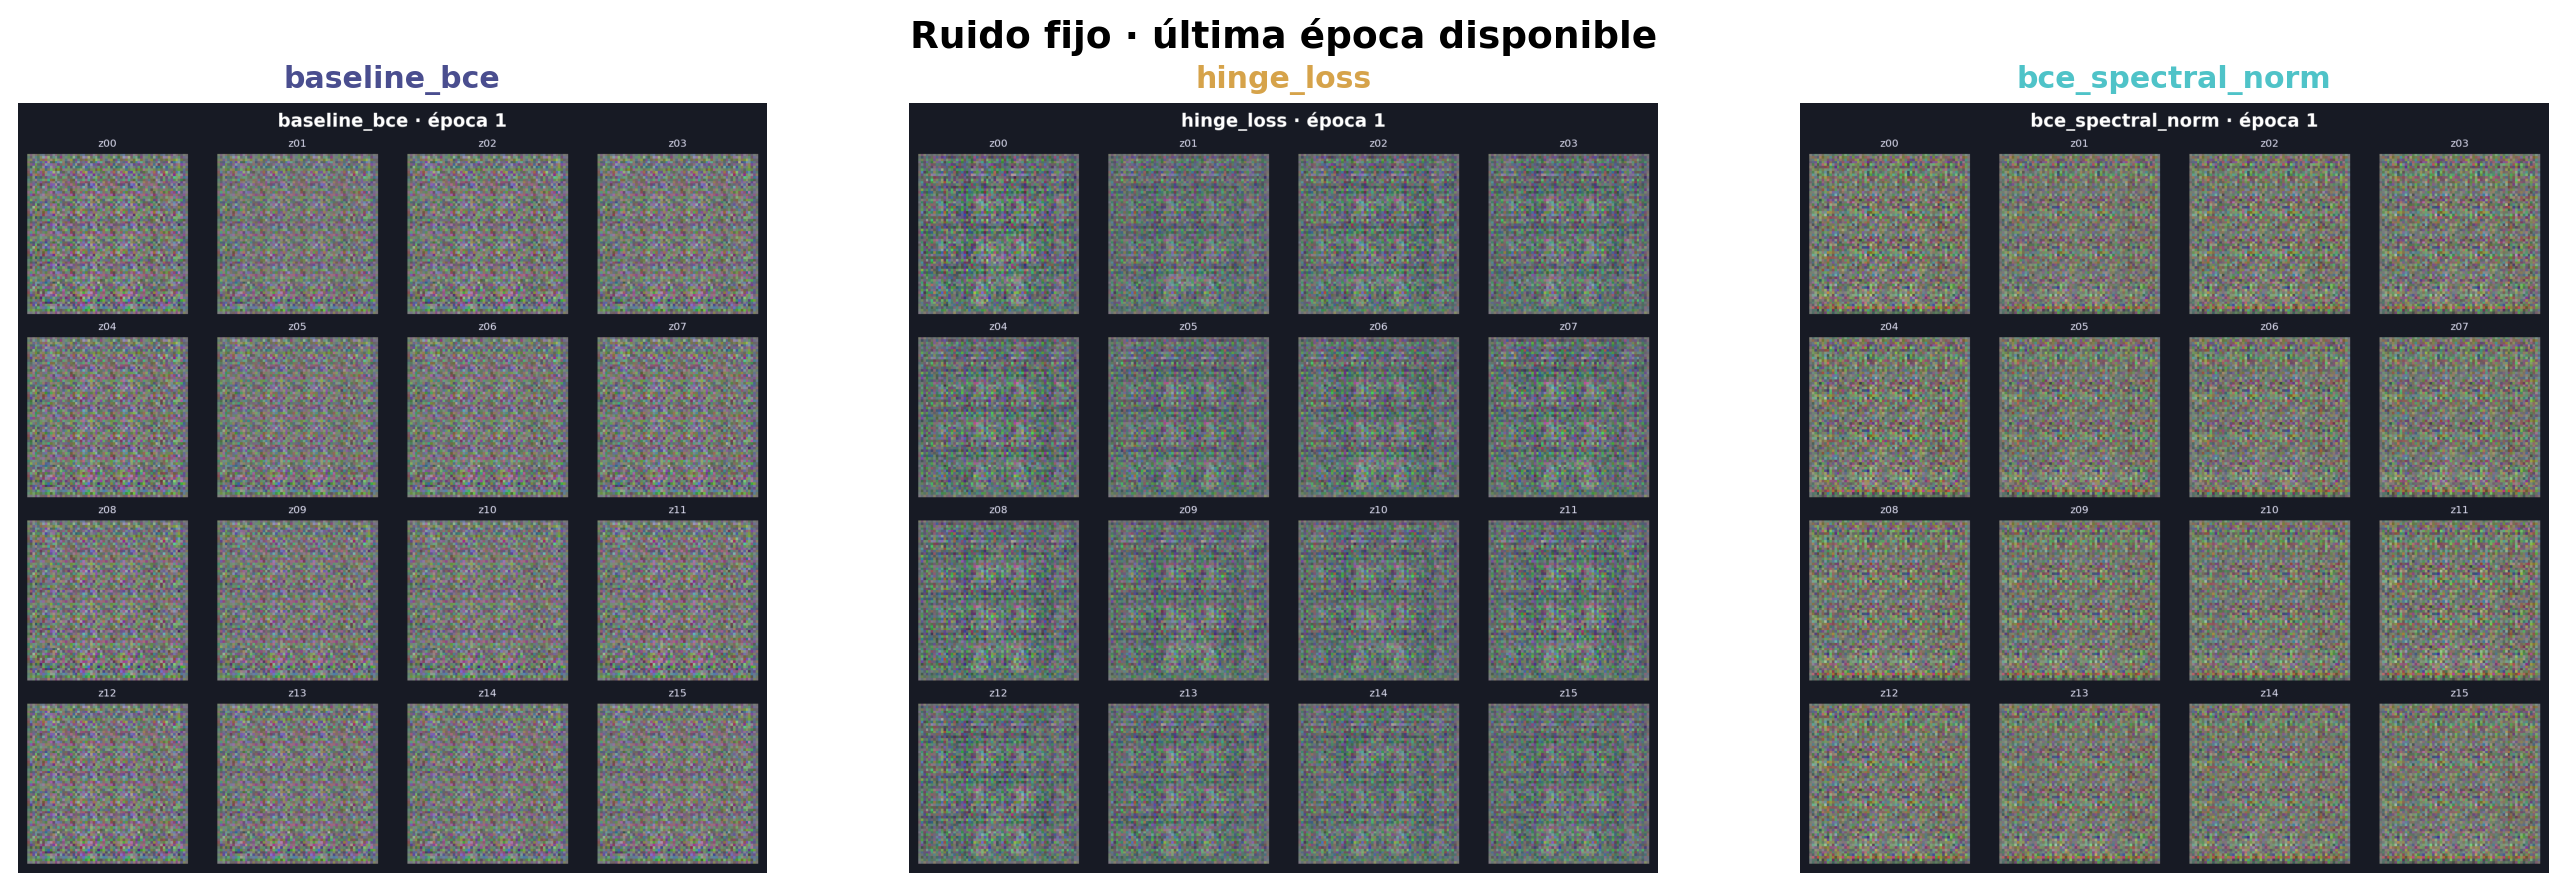

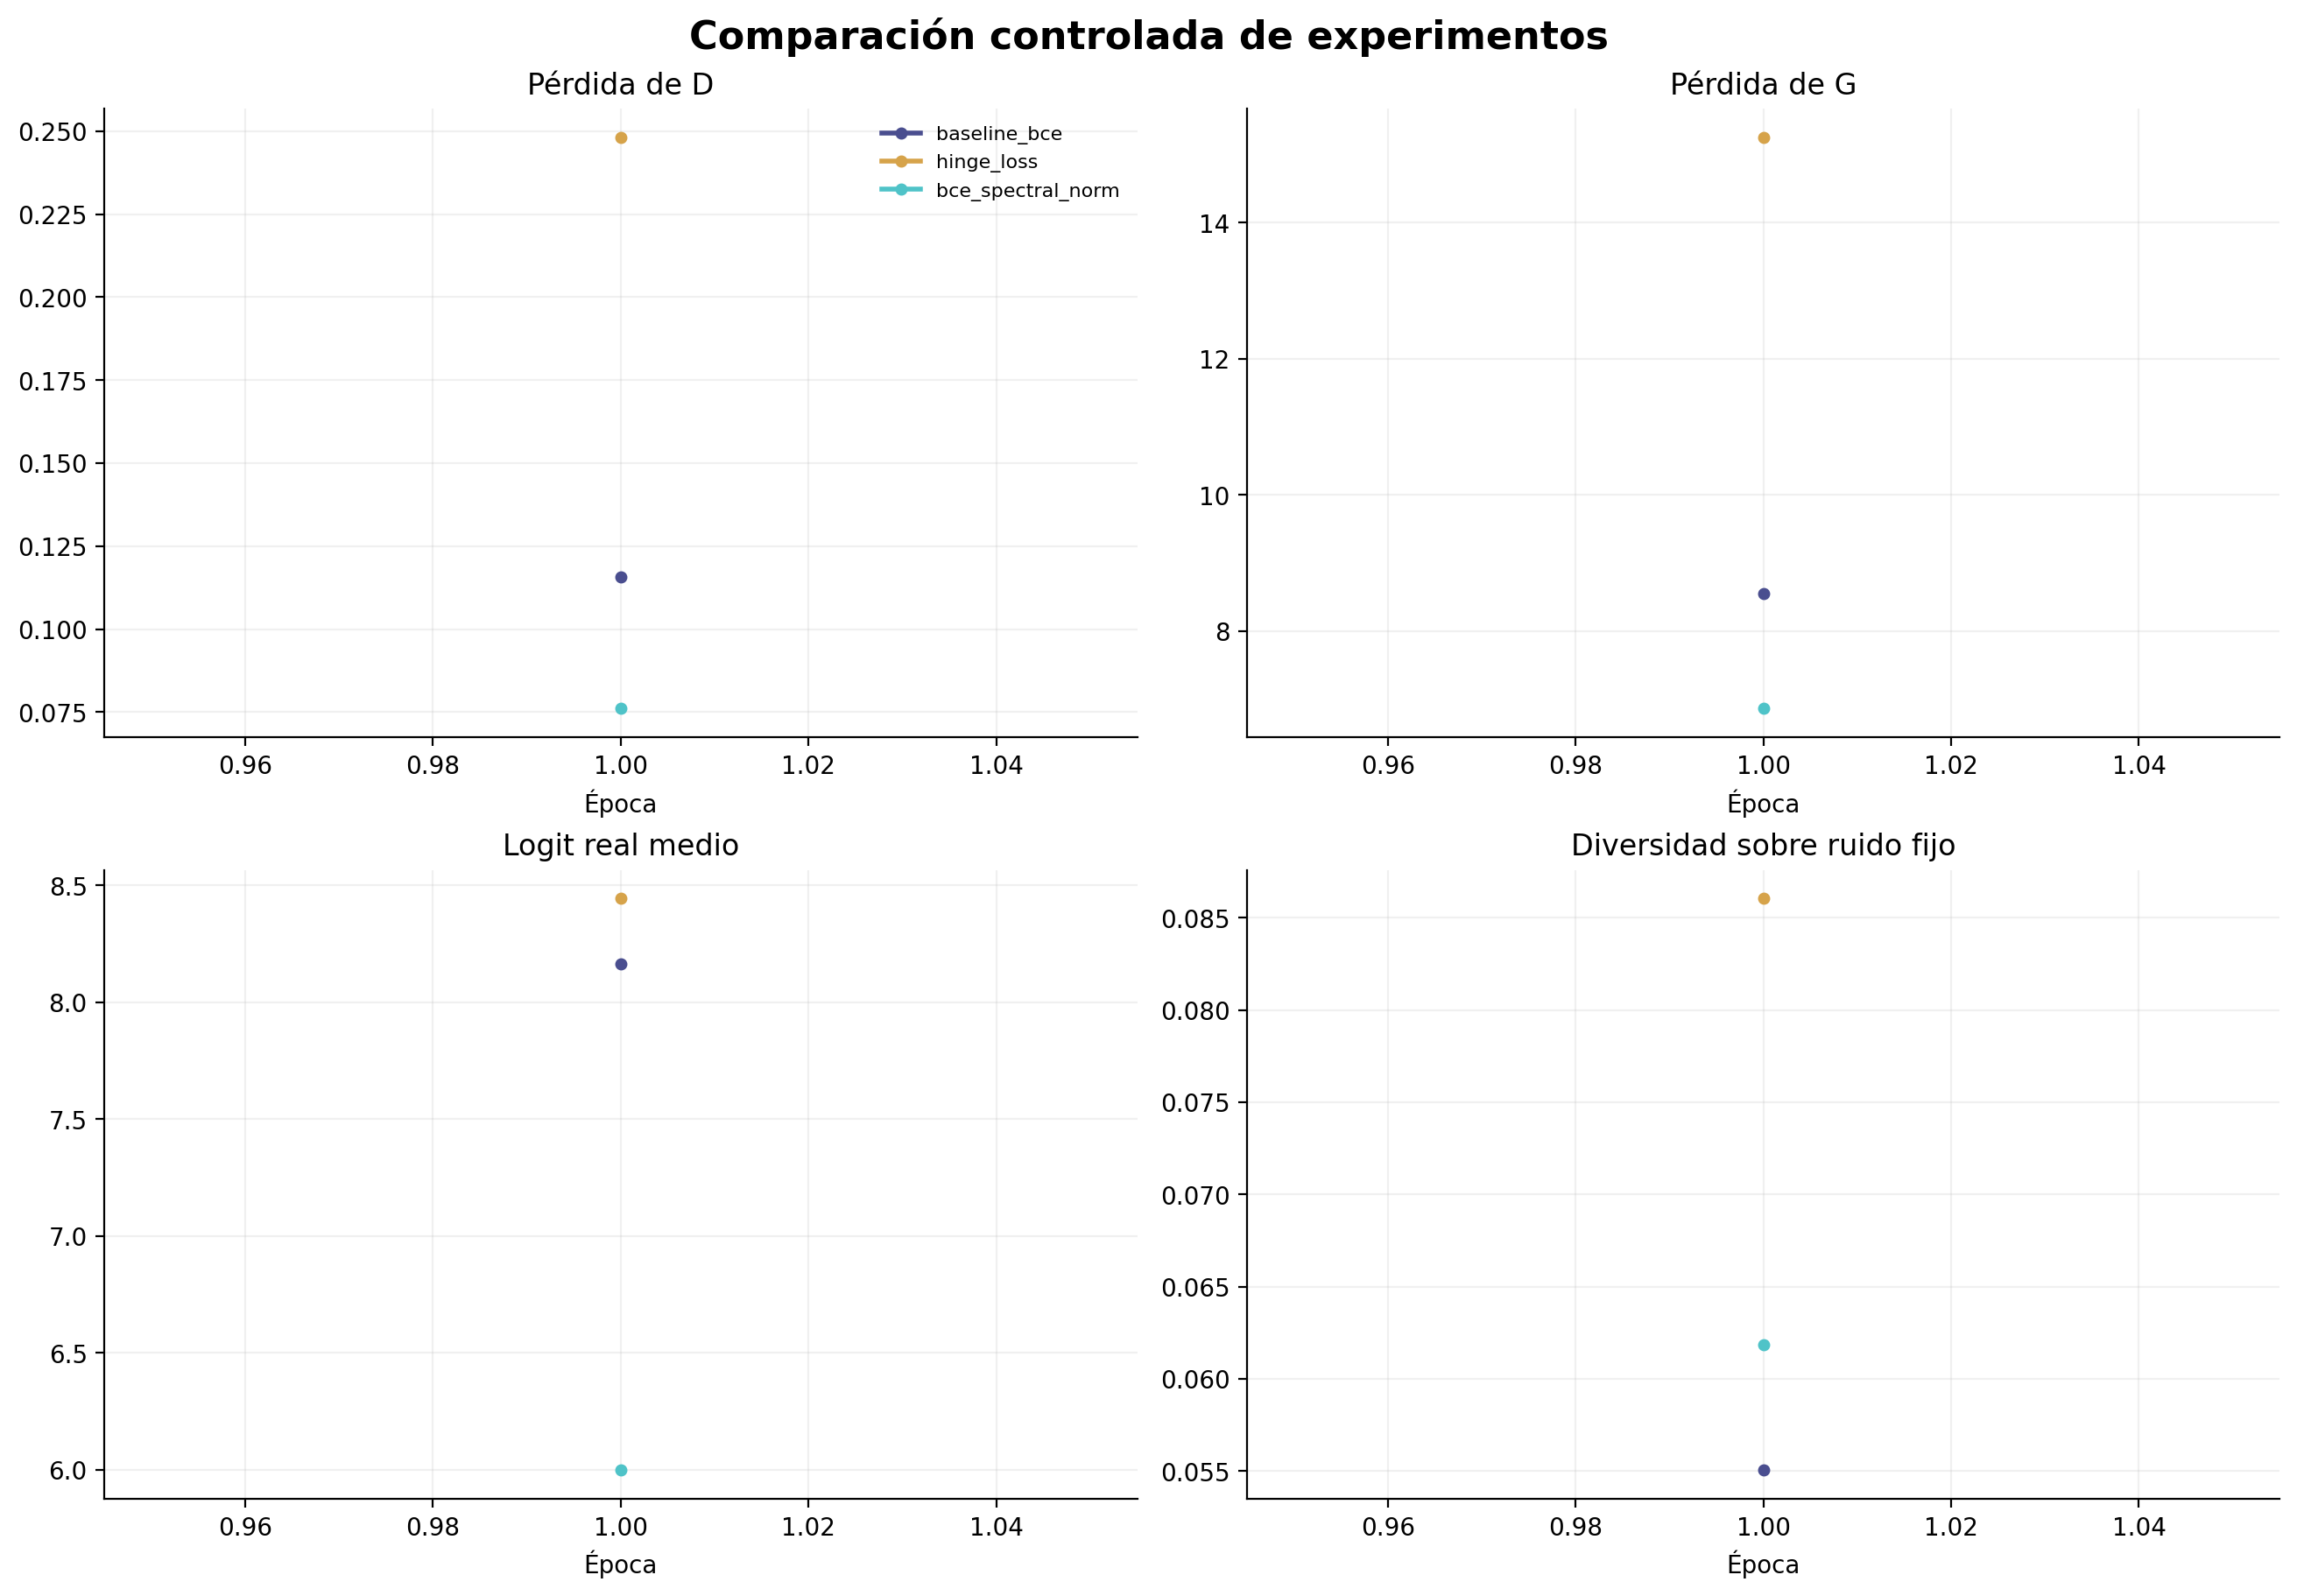

In [12]:
display(IPyImage(
    filename=str(ROOT / "artifacts" / "experiments" / "latest_fixed_noise_comparison.png"),
    width=1150,
))
display(IPyImage(
    filename=str(ROOT / "artifacts" / "experiments" / "experiment_comparison.png"),
    width=1050,
))

### 9.1 Interpretación provisional

- Las tres corridas terminaron la época 1 con métricas finitas y checkpoint válido.
- El discriminador ya separa con fuerza datos reales y falsos en las tres variantes; es una señal de desbalance temprano que debe seguirse en las rejillas y logits.
- `hinge_loss` presenta la mayor distancia media entre muestras del ruido fijo (**0.0860**), pero este único dato todavía no demuestra mejor diversidad.
- Las rejillas continúan dominadas por textura de alta frecuencia y no contienen personajes reconocibles. Presentarlas como resultado final sería incorrecto.
- Las épocas medidas tomaron entre 184 y 205 segundos en CPU; completar las 59 restantes de cada corrida requiere aproximadamente 9.4 horas en este equipo.

La reanudación secuencial se ejecuta con:

```powershell
python scripts\train_all.py --epochs 60 --device auto
```

## 10. Evidencias que deberá completar el entrenamiento

### 10.1 Rejilla de ruido fijo

Se usarán los mismos 16 vectores en las épocas 0, 5, 10, 20, 40 y 60.

### 10.2 Curvas interpretadas

Se registrarán pérdidas de G y D, logits medios sobre datos reales y falsos, y tiempo por época. Las curvas no se interpretarán como si ambas pérdidas debieran disminuir juntas.

### 10.3 Vecinos más cercanos

Cada personaje final se comparará contra todas las imágenes de entrenamiento mediante embeddings de ResNet18 y similitud coseno, con MSE en píxeles como comprobación secundaria.

## 11. Protocolo de galería

1. Generar 200 candidatos con semilla `20261011`.
2. Eliminar resultados técnicamente degenerados mediante reglas declaradas.
3. Priorizar distancia al vecino de entrenamiento.
4. Seleccionar de forma greedy para favorecer diversidad entre candidatos.
5. Escoger 10 personajes y declarar una tasa de selección de `10/200 = 5%`.
6. Guardar PNG, vector latente, semilla, vecino, similitud y comentario en `manifest.csv`.

Los nombres y clases de personaje se agregarán después de la selección como trabajo creativo adicional; no afectarán el criterio técnico.

## 12. Implementación de la fase 5

El pipeline final ya está implementado, pero **no escribirá imágenes en `galeria/` mientras el checkpoint seleccionado tenga menos de 60 épocas**. Esta barrera evita confundir ruido temprano con personajes finales.

Cuando el entrenamiento esté completo, el flujo será:

1. generar exactamente 200 candidatos en CPU con semilla `20261011`;
2. derivar límites de ocupación y contraste desde las 4,096 imágenes reales;
3. extraer características con ResNet18 preentrenada, sin reemplazo silencioso por pesos aleatorios;
4. localizar el vecino real con máxima similitud coseno y calcular MSE en píxeles;
5. elegir 10 mediante una selección greedy que combina novedad, calidad técnica y separación entre elegidos;
6. guardar PNG, `latents.npz`, `manifest.csv`, procedencia, rejilla y figura de vecinos;
7. regenerar las diez imágenes y exigir diferencia máxima RGB igual a cero.

In [13]:
readiness_path = ROOT / "artifacts" / "gallery" / "readiness.json"
pipeline_smoke_path = ROOT / "artifacts" / "gallery" / "pipeline_smoke_test.json"
if not readiness_path.exists() or not pipeline_smoke_path.exists():
    raise FileNotFoundError(
        "Ejecute scripts/check_phase5_readiness.py y scripts/smoke_test_evaluation.py"
    )
with open(readiness_path, encoding="utf-8") as file:
    PHASE5 = json.load(file)
with open(pipeline_smoke_path, encoding="utf-8") as file:
    PHASE5_SMOKE = json.load(file)

assert PHASE5_SMOKE["status"] == "passed"
display(HTML(f"""
<div class="kpis">
  <div class="kpi"><span>Pipeline</span><strong>{PHASE5_SMOKE['status'].upper()}</strong></div>
  <div class="kpi"><span>Preparación final</span><strong>{PHASE5['status'].upper()}</strong></div>
  <div class="kpi"><span>Candidatos</span><strong>{CONFIG['gallery']['candidate_count']}</strong></div>
  <div class="kpi"><span>Selección declarada</span><strong>10 / 200</strong></div>
</div>
"""))

phase5_progress = pd.DataFrame([
    {"Experimento": key, "Épocas": value, "Objetivo": PHASE5["target_epochs"]}
    for key, value in PHASE5["completed_epochs"].items()
])
display(phase5_progress.style.hide(axis="index"))
print("Bloqueos activos:")
for reason in PHASE5["blocking_reasons"]:
    print(f"- {reason}")

Experimento,Épocas,Objetivo
baseline_bce,1,60
hinge_loss,1,60
bce_spectral_norm,1,60


Bloqueos activos:
- baseline_bce: 1/60 épocas
- hinge_loss: 1/60 épocas
- bce_spectral_norm: 1/60 épocas
- pesos preentrenados ResNet18 aún no están en caché


### 12.1 Comandos finales

```powershell
python scripts\check_phase5_readiness.py
python scripts\build_gallery.py --experiment <experimento_seleccionado>
python scripts\validate_gallery.py
```

<div class="callout gold"><strong>Resultado actual honesto.</strong> La prueba sintética del algoritmo aprobó, pero no constituye evidencia de la GAN. La galería seguirá vacía hasta completar el entrenamiento, comparar A/B/C y seleccionar un checkpoint defendible.</div>

## 13. Estado actual y fase 7

<div class="callout magic"><strong>Entrenamiento preparado para Colab.</strong> El notebook <code>02_entrenamiento_colab.ipynb</code> restaura checkpoints, usa CUDA y refleja el estado crítico a Google Drive al terminar cada época. Los tres experimentos permanecen en 1/60 hasta ejecutarlo; por ello todavía no existe un modelo seleccionado ni una galería válida.</div>

### Siguiente fase

- ejecutar `notebooks/02_entrenamiento_colab.ipynb` con GPU;
- reanudar los tres experimentos desde la época 2 hasta la 60;
- pasar a la fase 8 para interpretar pérdidas, logits, diversidad y muestras por época;
- actualizar automáticamente las presentaciones HTML y PDF con la evidencia completa.

### Referencias metodológicas

- Kassis, T., Agarwal, V., He, Y., Patel, D., & Brueckner, A. M. (2026). *Scientific Agent Skills: A Library of Procedural Knowledge for Research Agents*. arXiv:2609.00065.
- Universal LPC Spritesheet Character Generator y su `CREDITS.csv`.
- Liberated Pixel Cup Style Guide.